In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/National_Stock_Exchange_of_India_Ltd.csv")

In [ ]:
df

,Symbol,Open,High,Low,LTP,Chng,% Chng,Volume (lacs),Turnover (crs.),52w H,52w L,365 d % chng,30 d % chng
0,ADANIPORTS,750,766,713.25,715,-47.45,-6.22,72.20,532.63,901,384.4,79.22,-4.65
1,ASIANPAINT,"3,101.00","3,167.35","3,091.00","3,138.00",-6.25,-0.20,10.29,322.53,"3,505.00","2,117.15",45.66,5.66
2,AXISBANK,669,674.9,660.45,661,-18.90,-2.78,102.53,684,866.9,568.4,10.19,-21.49
3,BAJAJ-AUTO,"3,370.00","3,383.50","3,320.00","3,335.00",-56.70,-1.67,3.42,114.59,"4,361.40","3,041.00",9.30,-12.05
4,BAJAJFINSV,"17,200.00","17,237.20","16,610.00","16,684.00",-684.85,-3.94,3.42,576.79,"19,325.00","8,273.70",91.38,-9.10
5,BAJFINANCE,"7,021.00","7,047.90","6,775.00","6,780.00",-345.80,-4.85,16.89,"1,161.63","8,050.00","4,362.00",44.57,-13.69
6,BHARTIARTL,763,763,733.1,735.85,-29.30,-3.83,111.43,830.06,781.8,454.11,58.55,5.70
7,BPCL,397.15,397.2,375,377.4,-22.70,-5.67,100.23,383.54,503,357,-1.22,-12.45
8,BRITANNIA,"3,560.00","3,635.10","3,533.95","3,566.60",-6.80,-0.19,3.73,133.23,"4,153.00","3,317.30",0.30,-3.42
9,CIPLA,892,976.05,890.65,965,65.05,7.23,144.59,"1,380.90","1,005.00",726.5,31.89,6.34


In [ ]:
cols = ['Open','High','Low','LTP','Turnover (crs.)']

for col in cols:
    df[col] = df[col].astype(str).str.replace(',', '')
    df[col] = df[col].astype(float)

In [ ]:
percent_cols = ['% Chng','365 d % chng','30 d % chng']

for col in percent_cols:
    df[col] = df[col].astype(str).str.replace('%','')
    df[col] = df[col].astype(float)

In [ ]:
df.rename(columns={
    'Volume (lacs)': 'Volume',
    'Turnover (crs.)': 'Turnover',
    '% Chng': 'Pct_Change',
    '365 d % chng': 'Year_Change',
    '30 d % chng': 'Month_Change'
}, inplace=True)

In [ ]:
df = df.dropna()

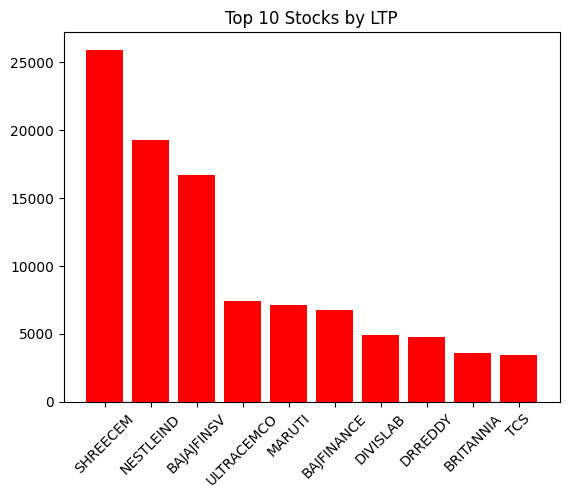

In [ ]:
top10 = df.sort_values(by='LTP', ascending=False).head(10)

plt.figure()
plt.bar(top10['Symbol'], top10['LTP'], color='red')
plt.title("Top 10 Stocks by LTP")
plt.xticks(rotation=45)
plt.show()

This chart shows the top 10 highest-priced stocks.
Higher bars mean higher stock prices.
It helps identify strong and leading companies.
Easy to compare different stocks quickly.

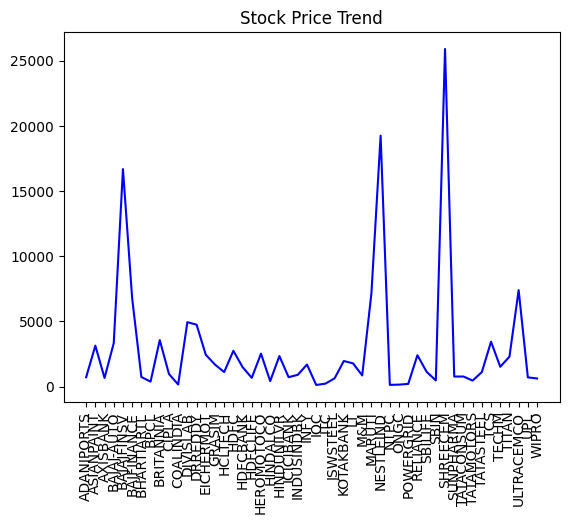

In [ ]:
plt.figure()
plt.plot(df['Symbol'], df['LTP'], color='blue')
plt.xticks(rotation=90)
plt.title("Stock Price Trend")
plt.show()

This chart shows the Last Traded Price (LTP) for each stock in your dataset. It helps visualize the current price levels across all listed companies, highlighting the relative valuation of each stock at a glance.



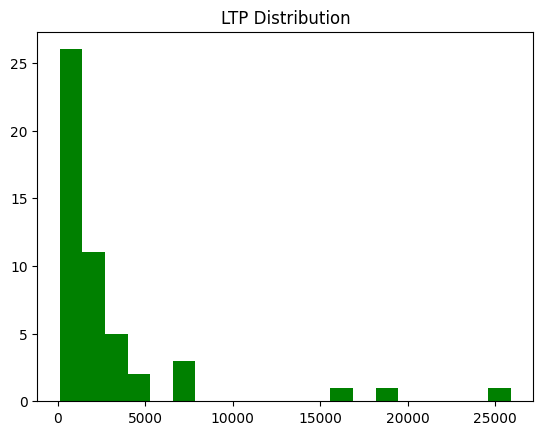

In [ ]:
plt.figure()
plt.hist(df['LTP'], bins=20, color='green')
plt.title("LTP Distribution")
plt.show()

This histogram shows the distribution of Last Traded Prices across all stocks, indicating the frequency of different price ranges. The chart reveals that most stocks in your dataset are concentrated within lower price brackets, with fewer stocks trading at higher prices.

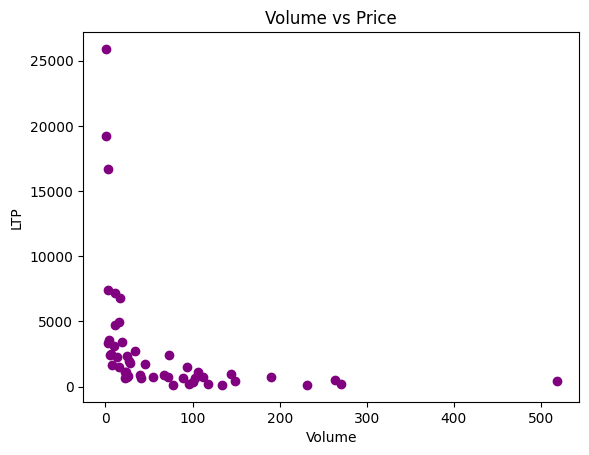

In [ ]:
plt.figure()
plt.scatter(df['Volume'], df['LTP'], color='purple')
plt.title("Volume vs Price")
plt.xlabel("Volume")
plt.ylabel("LTP")
plt.show()


This scatter plot shows the relationship between a stock's trading volume and its Last Traded Price (LTP). It helps identify if higher trading volumes correlate with higher or lower prices, or if there are any unusual price-volume relationships (outliers) among stocks.

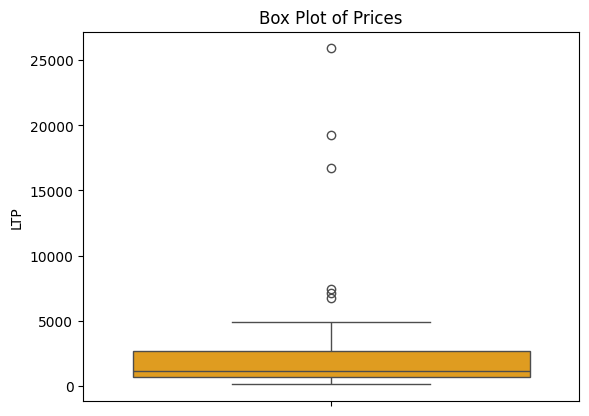

In [ ]:
plt.figure()
sns.boxplot(y=df['LTP'], color='orange')
plt.title("Box Plot of Prices")
plt.show()



This box plot displays the distribution of Last Traded Prices (LTP), showing the median, interquartile range, and potential outliers. It helps to quickly understand the central tendency and spread of stock prices, highlighting any unusually high or low-priced stocks.

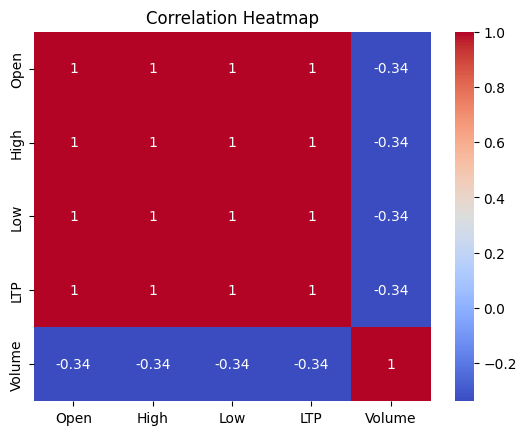

In [ ]:
plt.figure()
sns.heatmap(df[['Open','High','Low','LTP','Volume']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()



This heatmap displays the correlation coefficients between 'Open', 'High', 'Low', 'LTP', and 'Volume'. Values close to 1 indicate a strong positive correlation, while values close to -1 indicate a strong negative correlation. This helps to quickly understand how these financial metrics move in relation to each other.

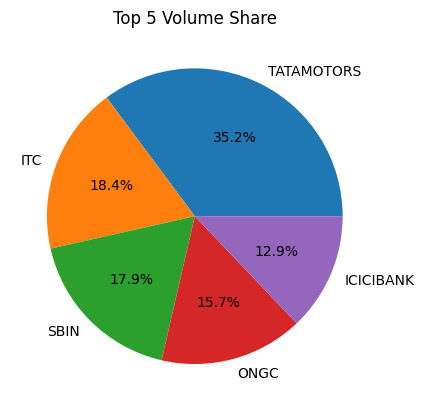

In [ ]:
top5 = df.sort_values(by='Volume', ascending=False).head(5)

plt.figure()
plt.pie(top5['Volume'], labels=top5['Symbol'], autopct='%1.1f%%')
plt.title("Top 5 Volume Share")
plt.show()



This pie chart illustrates the proportional trading volume contribution of the top 5 stocks with the highest volume. Each slice represents a stock, with its size indicating its share of the total trading volume among these top performers. This visualization quickly highlights which stocks are currently experiencing the most trading activity.

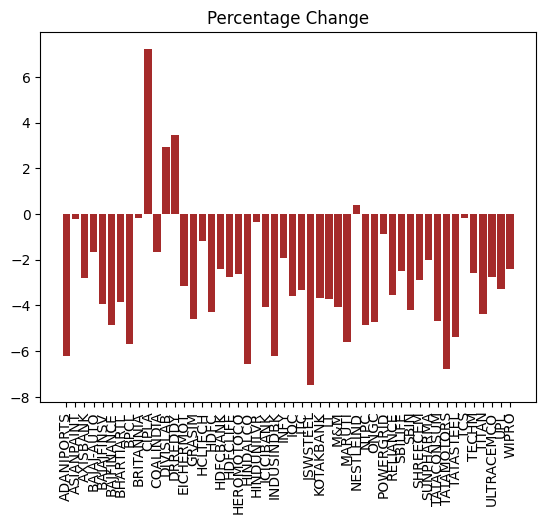

In [ ]:
plt.figure()
plt.bar(df['Symbol'], df['Pct_Change'], color='brown')
plt.xticks(rotation=90)
plt.title("Percentage Change")
plt.show()



This bar graph displays the daily percentage change for each stock. Positive bars indicate gains, while negative bars represent losses. It helps to quickly visualize the daily performance of individual stocks, making it easy to spot top performers and those experiencing significant downturns.

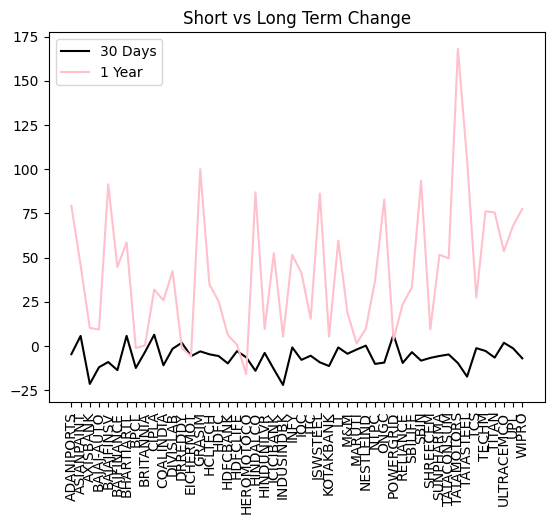

In [ ]:
plt.figure()
plt.plot(df['Symbol'], df['Month_Change'], label='30 Days', color='black')
plt.plot(df['Symbol'], df['Year_Change'], label='1 Year', color='pink')
plt.legend()
plt.xticks(rotation=90)
plt.title("Short vs Long Term Change")
plt.show()



This line plot compares the 30-day and 365-day percentage changes for each stock. It helps to quickly identify stocks with significant short-term fluctuations versus those with more consistent long-term trends. Divergences between these lines can signal potential shifts in market sentiment or underlying company performance.

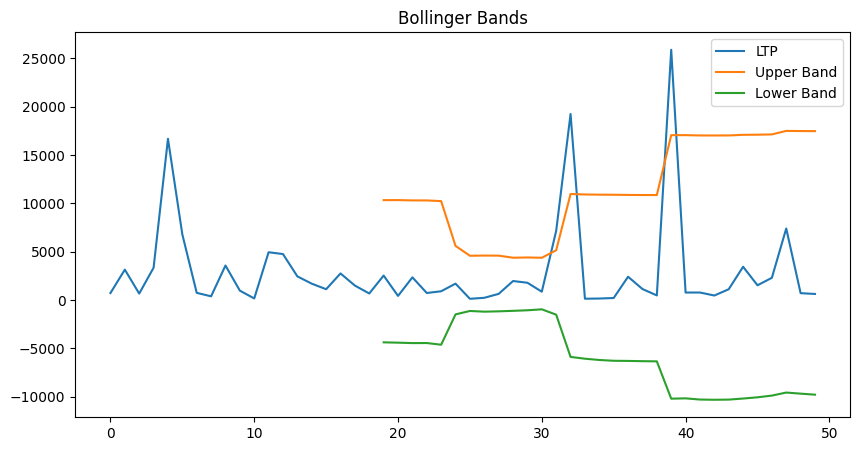

In [ ]:
df['MA20'] = df['LTP'].rolling(20).mean()
df['STD'] = df['LTP'].rolling(20).std()

df['Upper'] = df['MA20'] + (df['STD'] * 2)
df['Lower'] = df['MA20'] - (df['STD'] * 2)

plt.figure(figsize=(10,5))
plt.plot(range(len(df)), df['LTP'], label='LTP')
plt.plot(range(len(df)), df['Upper'], label='Upper Band')
plt.plot(range(len(df)), df['Lower'], label='Lower Band')
plt.legend()
plt.title("Bollinger Bands")
plt.show()



Bollinger Bands are a volatility indicator. When the bands are close together, it indicates low volatility, while wide bands suggest high volatility. Price movements outside the bands can signal overbought or oversold conditions, potentially indicating reversals or continuations.

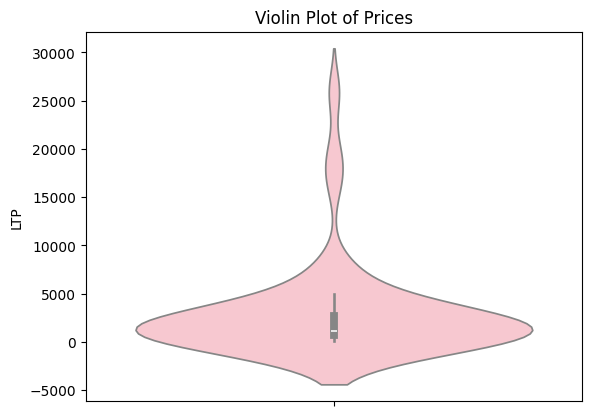

In [ ]:
plt.figure()
sns.violinplot(y=df['LTP'], color='pink')
plt.title("Violin Plot of Prices")
plt.show()



This violin plot illustrates the distribution of Last Traded Prices (LTP), combining elements of a box plot with a kernel density estimate. It shows the median, interquartile range, and also the probability density of the data at different values. This allows for a deeper understanding of the price distribution, revealing modes and spread that might not be evident from a simple box plot.

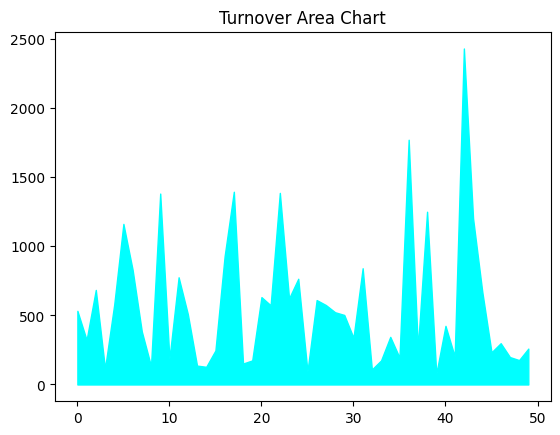

In [ ]:
plt.figure()
plt.fill_between(range(len(df)), df['Turnover'], color='cyan')
plt.title("Turnover Area Chart")
plt.show()

This area chart visualizes the Turnover (total value of traded shares) over time or across the dataset's entries. The filled area highlights the magnitude of turnover, making it easy to see periods of higher or lower market activity. It provides a quick overview of the overall market liquidity and engagement.

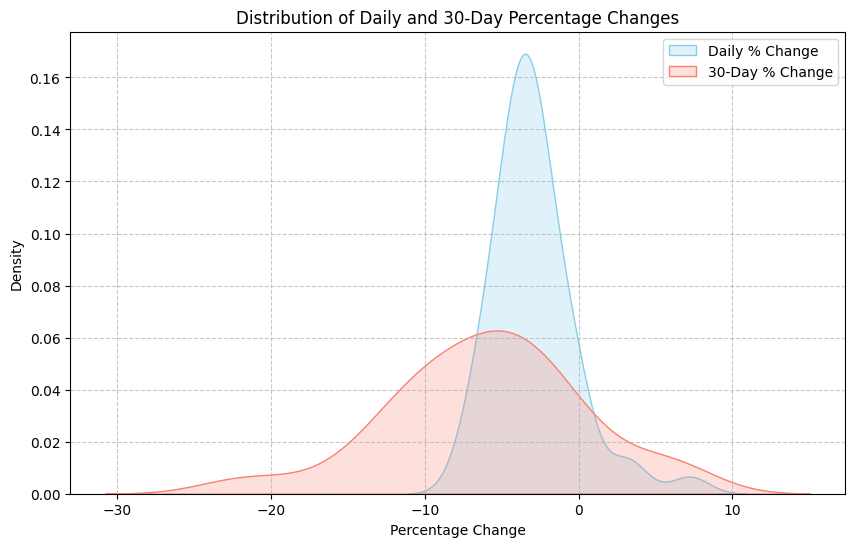

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df['Pct_Change'], fill=True, color='skyblue', label='Daily % Change')
sns.kdeplot(df['Month_Change'], fill=True, color='salmon', label='30-Day % Change')
plt.title('Distribution of Daily and 30-Day Percentage Changes')
plt.xlabel('Percentage Change')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()



This KDE plot reveals that both daily and 30-day percentage changes are skewed towards negative values, suggesting an overall downward market trend during the observed period. The spread of the curves indicates the volatility and diversity in performance among individual stocks. Specifically, many stocks experienced minor negative daily changes, while the 30-day view shows a wider range of both gains and losses.